In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_orders.csv", parse_dates=["Order_Date", "Ship_Date"])
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Section A: Top 10 Best-Selling Products by Sales
- What are the top 10 best-selling products?
- Which products generate the highest sales?
- Which products are rarely sold?
- Which products are important within each category?

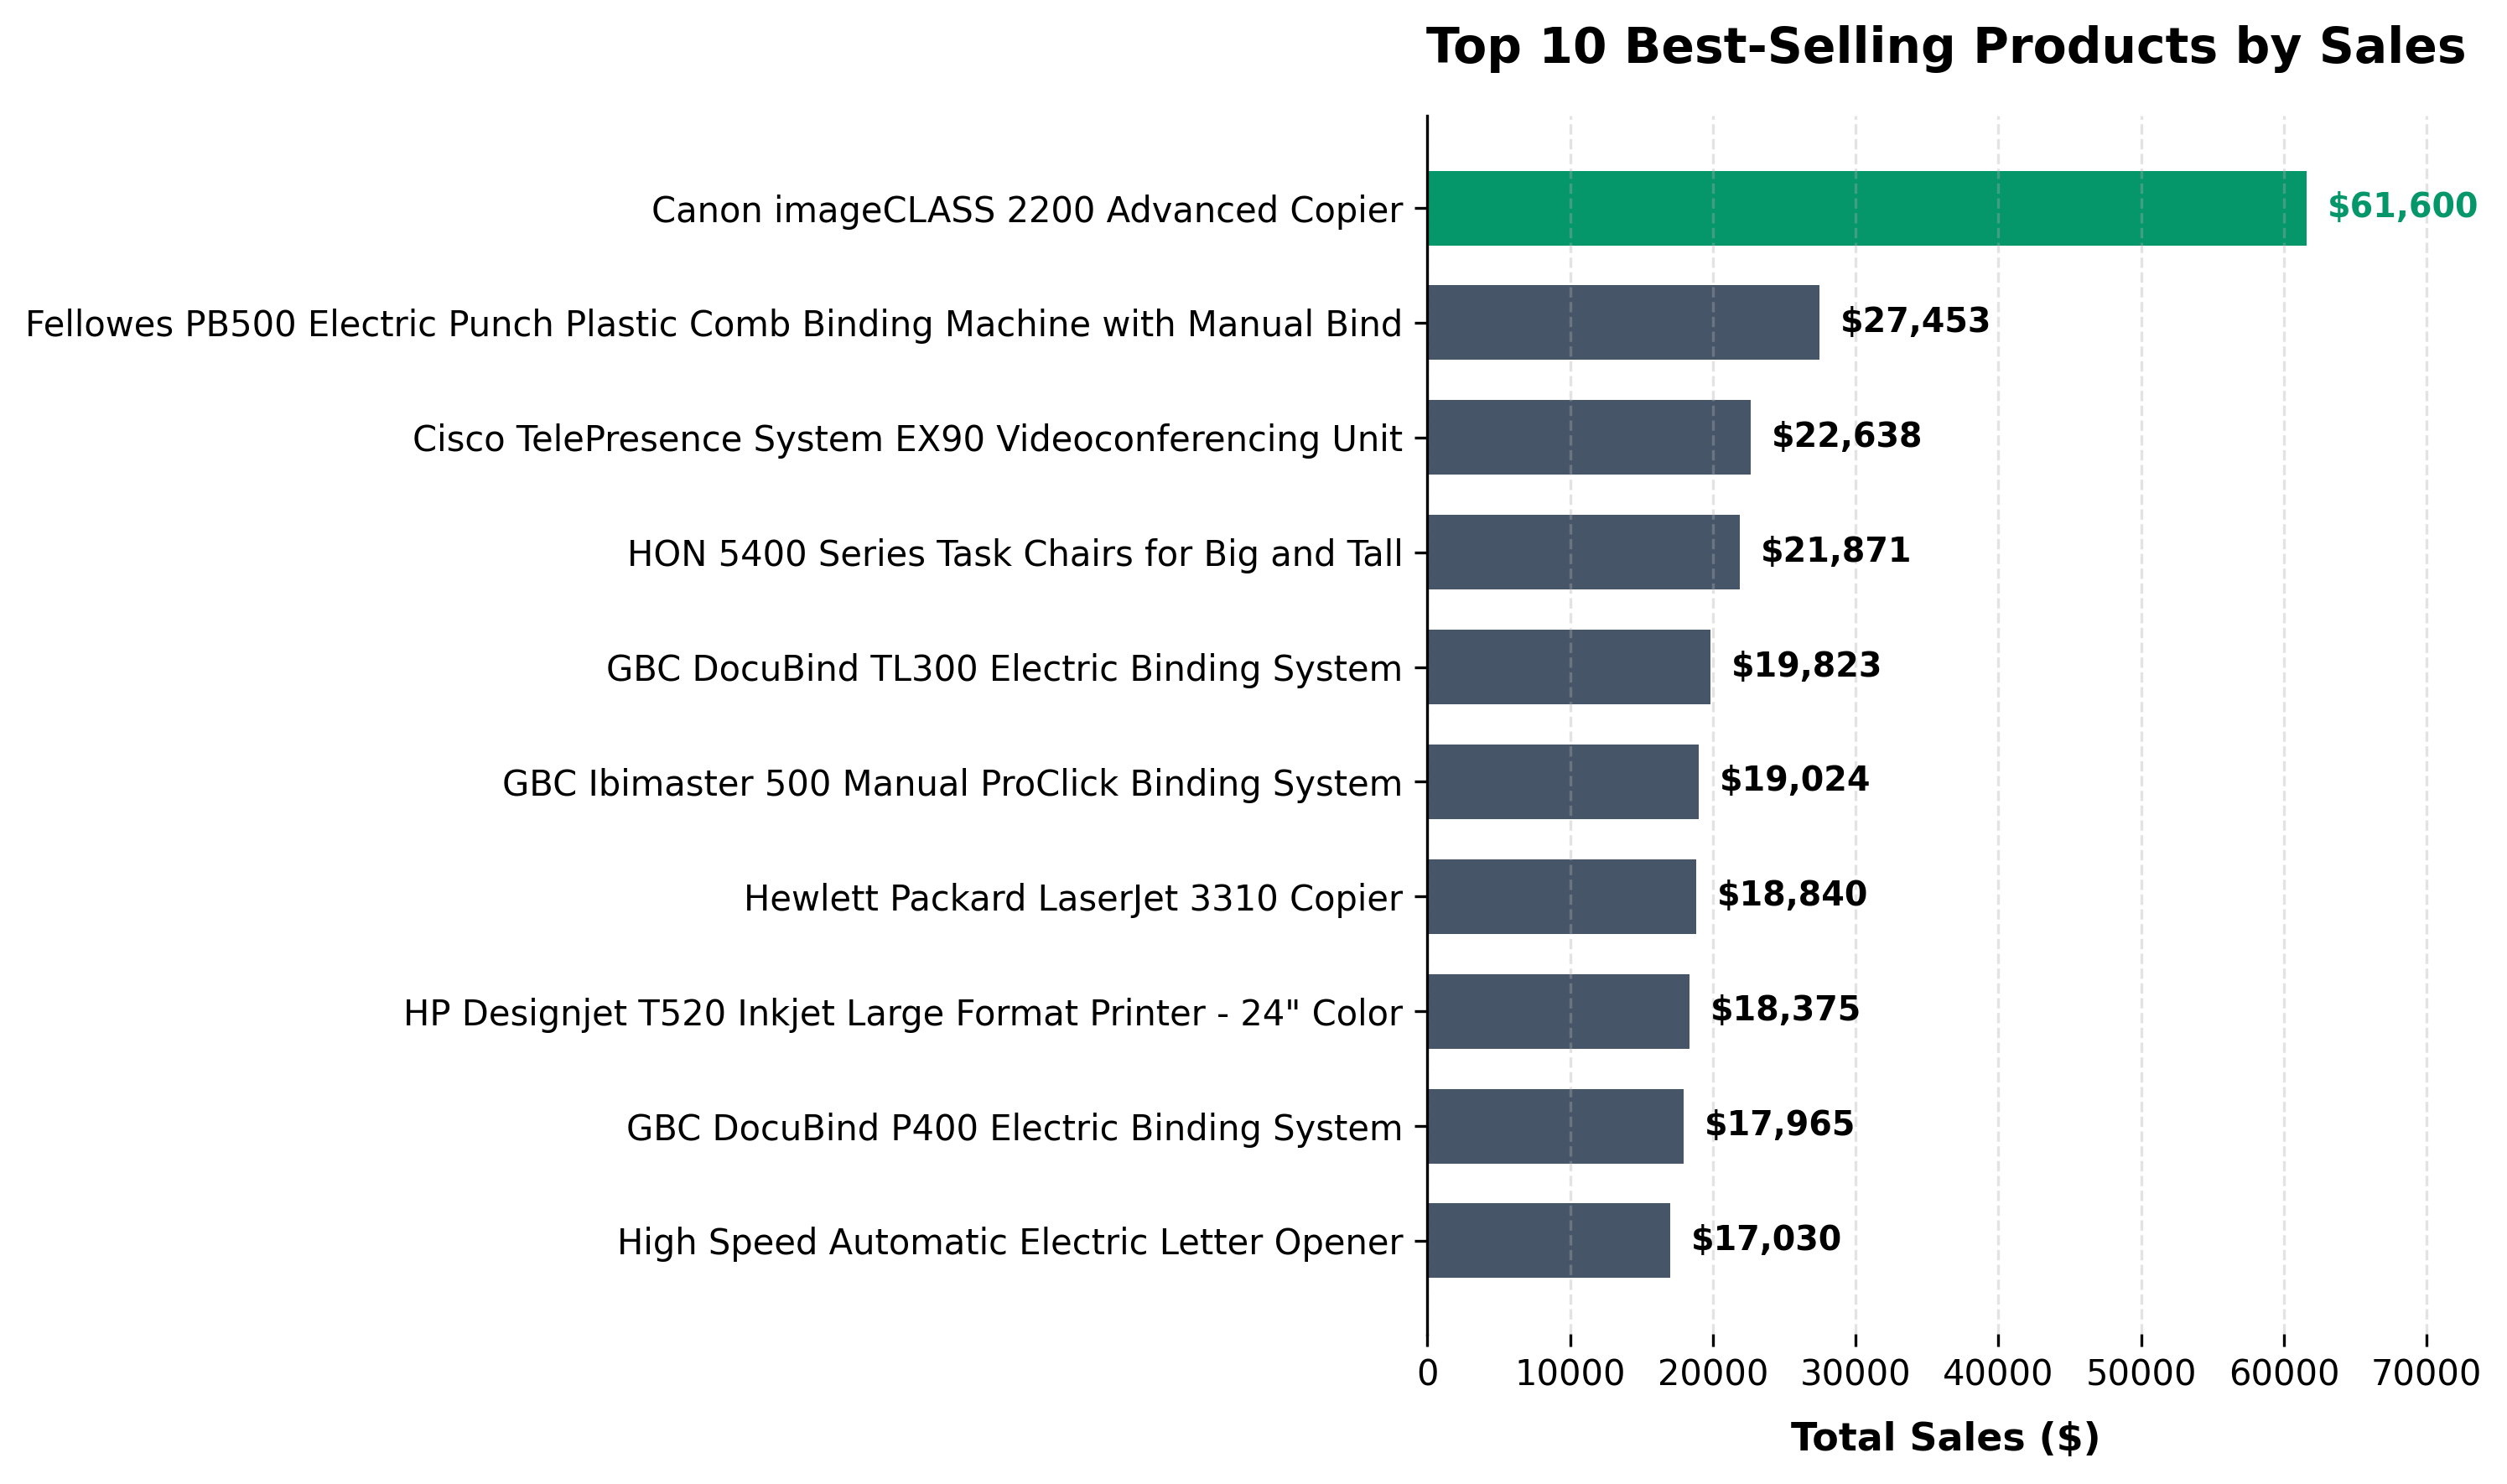

In [2]:
# 1. Top 10 Products Aggregation
top_products = (
    df.groupby("Product_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values() # Ascending ensures Rank 1 stays at the top
)

# 2. Setup Figure & DPI
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 3. Highlight Colors (Rank 1 is Emerald, rest are Slate)
bar_colors = ["#475569" if val != top_products.max() else "#059669" for val in top_products.values]

# 4. Horizontal Bar Chart Plot
bars = ax.barh(
    top_products.index,
    top_products.values,
    color=bar_colors,
    edgecolor="none",
    height=0.65
)

# 5. Bar Labels Formatting (Clean & Error-Free)
ax.bar_label(
    bars,
    labels=[f"${x:,.0f}" for x in top_products],
    padding=6,
    fontsize=9.5,
    fontweight="bold"
)

# Highlight Top Product's Label Text
# Last bar is the max/top product
ax.texts[-1].set_color("#059669")

# 6. Spines Cleanliness & Axes Formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.ticklabel_format(style="plain", axis="x")
plt.xlim(0, top_products.max() * 1.18)

# 7. Title & Labels
plt.title("Top 10 Best-Selling Products by Sales", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=8)
plt.ylabel("")

# Minimal Grid
plt.grid(axis="x", linestyle="--", alpha=0.35)

# 8. Save & Display
plt.tight_layout()
plt.savefig(
    "../reports/charts/top10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Category & Sub-Category Deep Dive

In [3]:
# Calculate total sales and total orders for each category
category_summary = df.groupby("Category").agg(
    total_sales=("Sales", "sum"),
    total_orders=("Order_ID", "nunique")
).sort_values("total_sales", ascending=False)

print(category_summary)

                 total_sales  total_orders
Category                                  
Technology       827455.8730          1519
Furniture        728658.5757          1727
Office Supplies  705422.3340          3676


In [4]:
# Calculate total sales for each sub-category within each category
subcat_by_category = df.groupby(["Category", "Sub-Category"])["Sales"].sum().sort_values(ascending=False)

print(subcat_by_category.head(15))

Category         Sub-Category
Technology       Phones          327782.4480
Furniture        Chairs          322822.7310
Office Supplies  Storage         219343.3920
Furniture        Tables          202810.6280
Office Supplies  Binders         200028.7850
Technology       Machines        189238.6310
                 Accessories     164186.7000
                 Copiers         146248.0940
Furniture        Bookcases       113813.1987
Office Supplies  Appliances      104618.4030
Furniture        Furnishings      89212.0180
Office Supplies  Paper            76828.3040
                 Supplies         46420.3080
                 Art              26705.4100
                 Envelopes        16128.0460
Name: Sales, dtype: float64


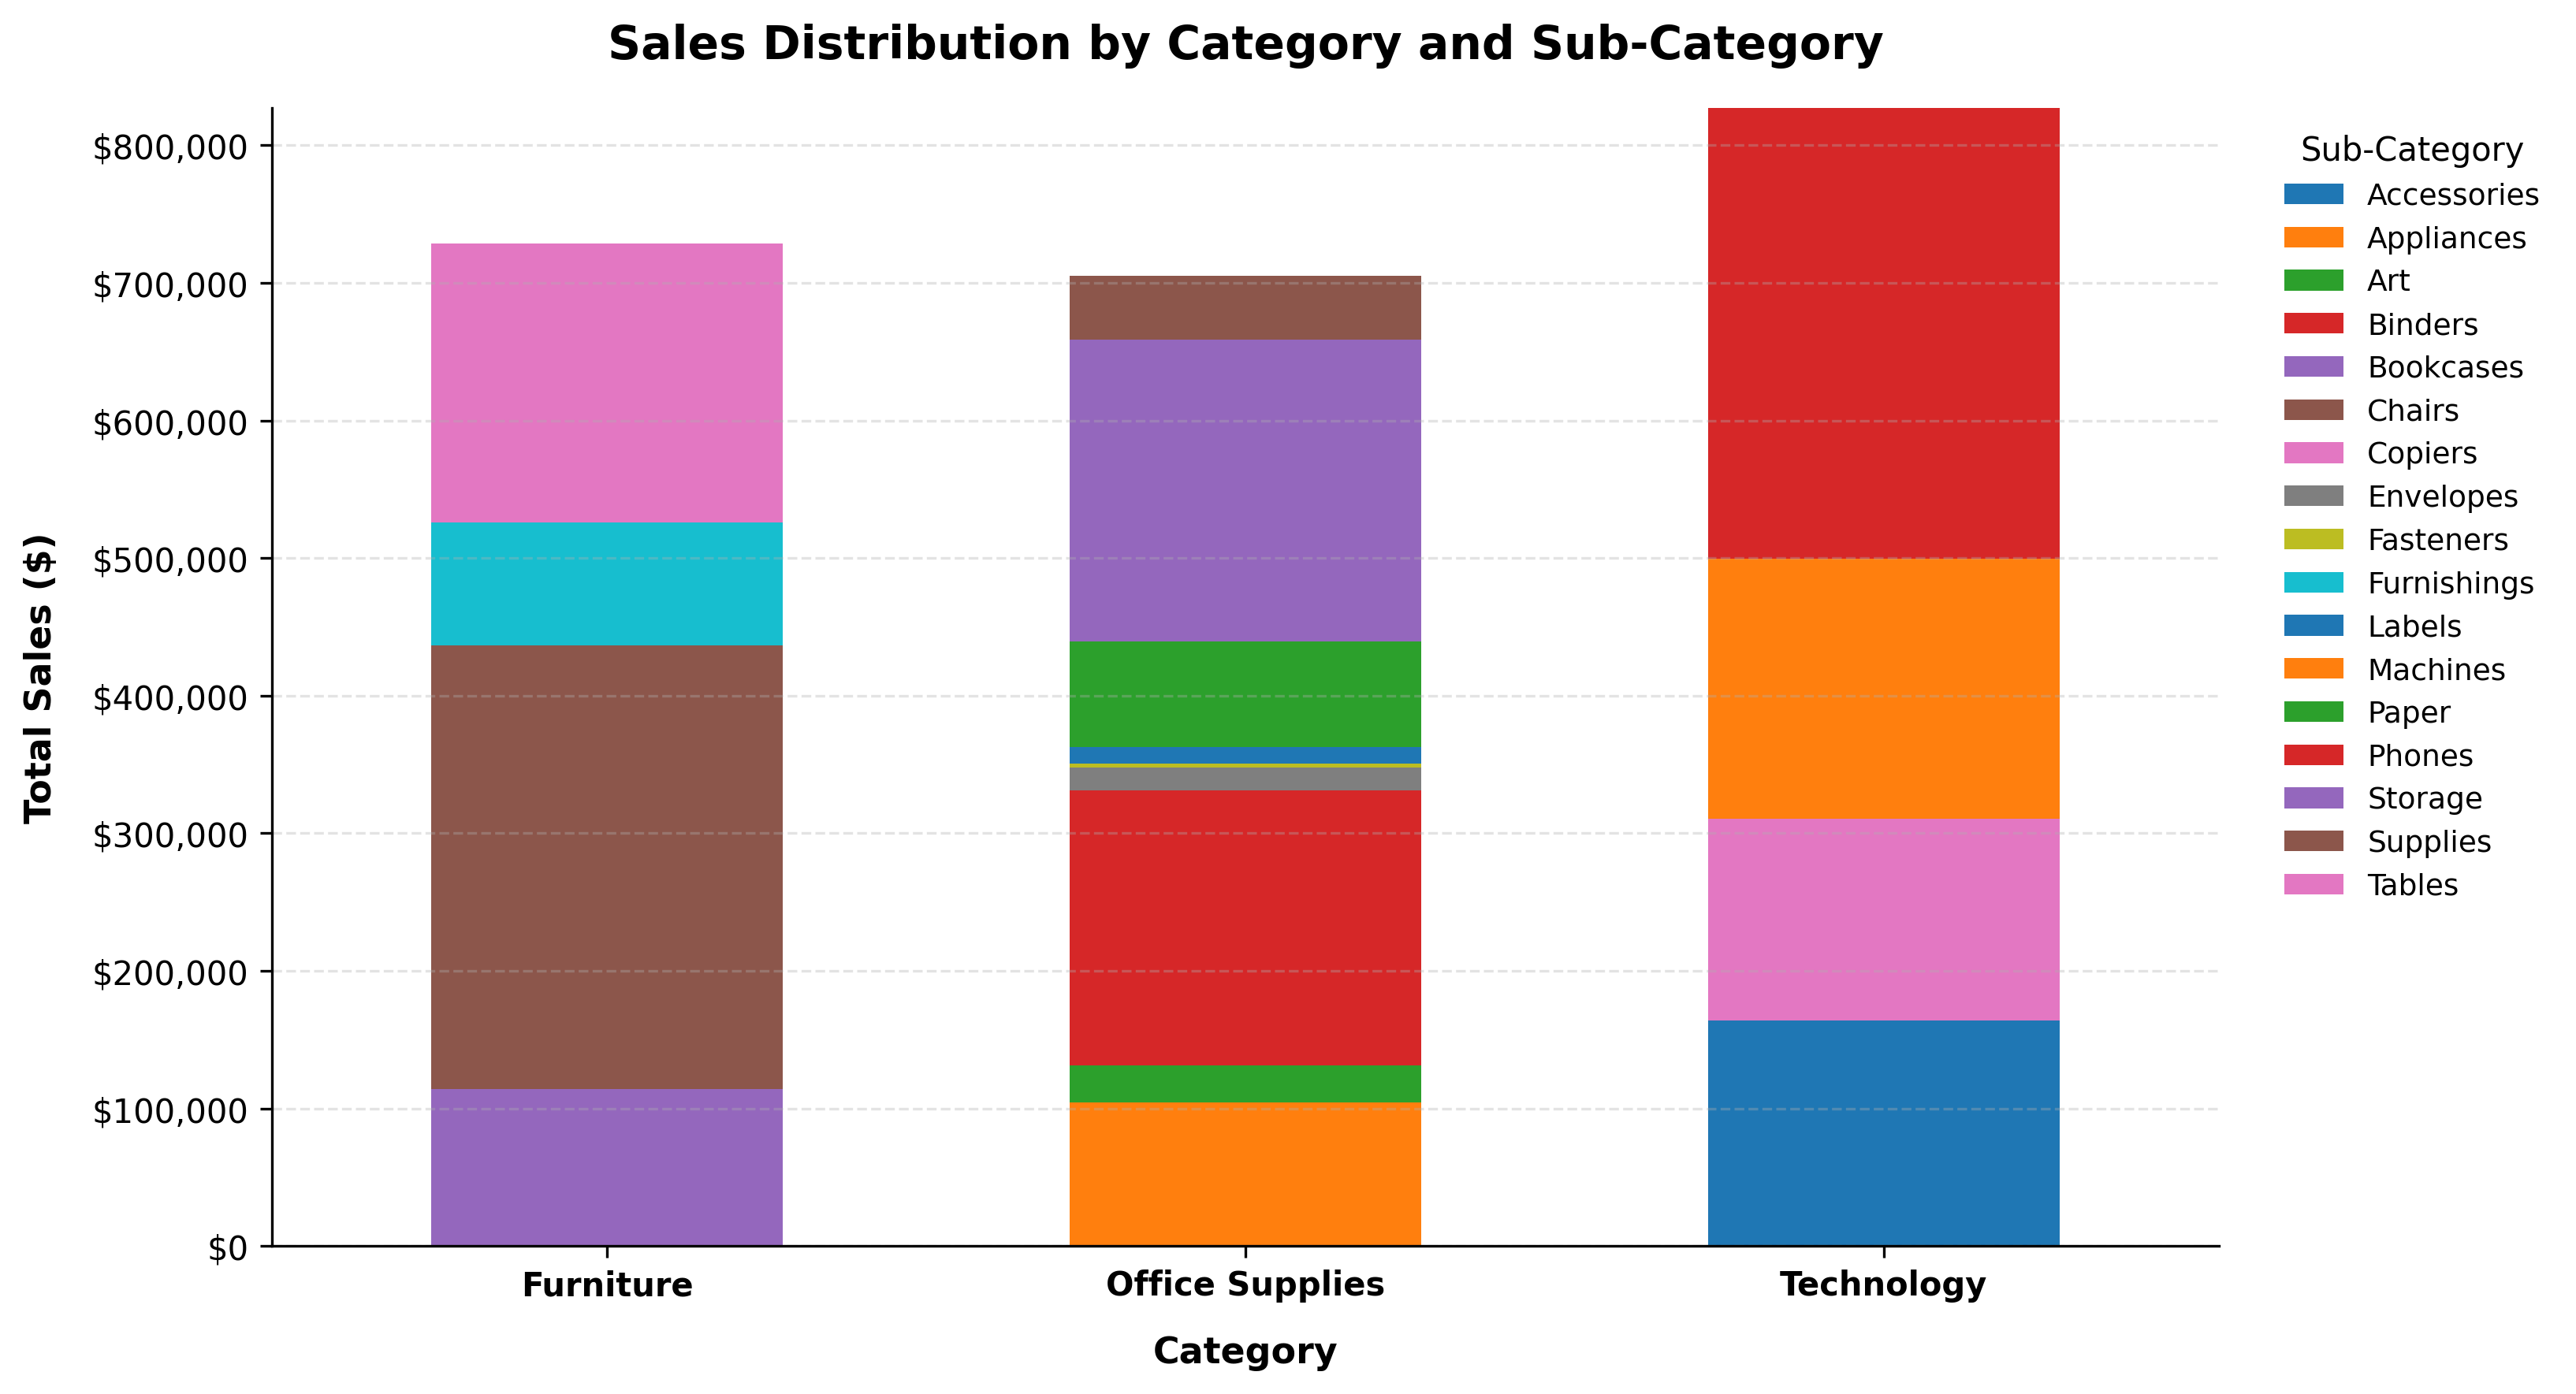

In [5]:
# 1. Groupby & Unstack Data
category_subcat = (
    df.groupby(["Category", "Sub-Category"])["Sales"]
    .sum()
    .unstack(fill_value=0) # Handle missing category and sub-category combinations with 0
)

# 2. Figure Setup & Stacked Bar Plot
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

category_subcat.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="none",
    width=0.55
)

# 3. Y-Axis Formatting (Plain numbers without scientific notation)
ax.ticklabel_format(style="plain", axis="y")

# Currency formatting on Y-ticks
ax.yaxis.set_major_formatter("${x:,.0f}")

# 4. Spines & Axes Cleanliness
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0, fontsize=10, fontweight="bold")
plt.xlabel("Category", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=10)
plt.title("Sales Distribution by Category and Sub-Category", fontsize=14, fontweight="bold", pad=15)

# 5. External Legend Positioning
plt.legend(
    title="Sub-Category",
    title_fontsize="10",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9
)

# Minimal Horizontal Grid
plt.grid(axis="y", linestyle="--", alpha=0.35)

# 6. Save & Display
plt.tight_layout()
plt.savefig(
    "../reports/charts/category_subcategory_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
df.head(2)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


### By Sales

In [6]:
# Identify the products generating the lowest total sales
low_performing_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=True).head(10)
print(low_performing_products)

Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64


### By Quantity

In [7]:
# Calculate the number of unique orders for each product
product_order_freq = df.groupby("Product_Name")["Order_ID"].nunique().sort_values(ascending=True)

# Filter products that were ordered only once
rarely_ordered = product_order_freq[product_order_freq == 1]

print(f"Products ordered only once: {len(rarely_ordered)}")

Products ordered only once: 94


In [8]:
# Calculate total sales for each product
product_sales = df.groupby("Product_Name")["Sales"].sum()

# Identify the top product by sales
top_product = product_sales.idxmax()

# Identify the best-performing category and sub-category
category_sales = df.groupby("Category")["Sales"].sum()
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum()

best_category = category_sales.idxmax()
best_subcategory = subcategory_sales.idxmax()

# Find the category that the best-performing sub-category belongs to
best_subcategory_category = (
    df[df["Sub-Category"] == best_subcategory]["Category"].iloc[0]
)

# Count products that were ordered only once
product_order_counts = df.groupby("Product_Name")["Order_ID"].nunique()
one_time_products = (product_order_counts == 1).sum()

# Identify the three lowest-performing products
lowest_products = product_sales.nsmallest(3).index.tolist()

# Calculate the contribution of the top 10 products to total sales
top_10_product_percentage = (
    product_sales.nlargest(10).sum() / df["Sales"].sum() * 100
)

print(f"Top 10 products contribution: {top_10_product_percentage:.2f}%")

print(f"Top product by sales: {top_product}")
print(f"Best-performing category: {best_category}")
print(f"Best-performing sub-category: {best_subcategory}")
print(f"Sub-category belongs to: {best_subcategory_category}")
print(f"Products ordered only once: {one_time_products}")
print(f"Lowest-performing products: {lowest_products}")

Top 10 products contribution: 10.82%
Top product by sales: Canon imageCLASS 2200 Advanced Copier
Best-performing category: Technology
Best-performing sub-category: Phones
Sub-category belongs to: Technology
Products ordered only once: 94
Lowest-performing products: ['Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac', 'Avery 5', 'Xerox 20']


## 📦 Product Analysis Summary

### Best-Selling Products
- Top product by sales: `Canon imageCLASS 2200 Advanced Copier`
- Top 10 products contribute `10.82%` of total sales

### Category Performance
- Best-performing category: `Technology`
- Best-performing sub-category: `Phones` (within the `Technology` category)

### Weak / Rarely Sold Products
- `94` products were ordered only once
- Lowest-performing products: `Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac`, `Avery 5`, `Xerox 20`

### Profitability
- Profit data is not available in the dataset, so profitability cannot be analyzed.

### 💡 Business Insight
The `Technology` category's `Phones` sub-category is the strongest-performing
segment and should be prioritized for inventory stocking and marketing
campaigns. Meanwhile, `94` products were ordered only once, indicating
limited repeat demand. These products may require further investigation
before considering bundling or clearance promotions.